In [1]:
from zipfile import ZipFile
import random
import torch

import torchvision
from torchvision import transforms
from PIL import Image, ImageOps, ImageFilter

import numpy as np
from typing import List
import matplotlib.pyplot as plt

/mnt/sw/nix/store/gpkc8q6zjnp3n3h3w9hbmbj6gjbxs85w-python-3.10.10-view/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/mnt/sw/nix/store/6qvrglgqdpwhbw9zv2nh07fpd7a4wq31-py-torchvision-0.15.2/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
class Zip_ImageFolder(torchvision.datasets.ImageFolder):
    def __init__(self, zip_path, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.zip_path = zip_path
        self.zip_archvive = None

    def __getitem__(self, index: int):
        path, target = self.samples[index]
        if self.zip_archvive is None:
            self.zip_archvive = ZipFile(self.zip_path)

        path_split = path.split("/")
        fh = self.zip_archvive.open(
            path_split[-3] + "/" + path_split[-2] + "/" + path_split[-1]
        )

        image = Image.open(fh)
        sample = image.convert("RGB")

        if self.transform is not None:
            sample = self.transform(sample)

        if self.target_transform is not None:
            sample = self.target_transform(sample)

        return sample, target

In [3]:
class ImageNetValTransform:
    def __init__(self):
        self.transform = transforms.Compose(
            [
                transforms.Resize(256),
                transforms.CenterCrop(224),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )

    def __call__(self, x):
        return self.transform(x)


class Solarization(object):
    def __init__(self, p):
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:
            return ImageOps.solarize(img)
        else:
            return img


class GaussianBlur(object):
    def __init__(self, p, min_sigma=0.1, max_sigma=2.0):
        self.p = p
        self.min_sigma = min_sigma
        self.max_sigma = max_sigma

    def __call__(self, img):
        if random.random() < self.p:
            sigma = random.random() * (self.max_sigma - self.min_sigma) + self.min_sigma
            return img.filter(ImageFilter.GaussianBlur(sigma))
        else:
            return img


class Barlow_Transform:
    def __init__(self, include_rotations=False, rotation_max_degree=0):

        self.transform = transforms.Compose(
            [
                transforms.RandomResizedCrop(224, interpolation=Image.BICUBIC),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomApply(
                    [
                        transforms.ColorJitter(
                            brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1
                        )
                    ],
                    p=0.8,
                ),
                transforms.RandomGrayscale(p=0.2),
                GaussianBlur(p=1.0),
                Solarization(p=0.0),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )
        self.transform_prime = transforms.Compose(
            [
                transforms.RandomResizedCrop(224, interpolation=Image.BICUBIC),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomApply(
                    [
                        transforms.ColorJitter(
                            brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1
                        )
                    ],
                    p=0.8,
                ),
                transforms.RandomGrayscale(p=0.2),
                GaussianBlur(p=0.1),
                Solarization(p=0.2),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )

    def __call__(self, x):
        y1 = self.transform(x)
        y2 = self.transform_prime(x)

        return y1, y2

In [4]:
imagenet_100_path = '/mnt/ceph/users/tyerxa/datasets/imagenet_100/'
train_data = Zip_ImageFolder(
    zip_path=imagenet_100_path + "train.zip",
    root=imagenet_100_path + "train/",
    transform=Barlow_Transform(),
)
test_data = Zip_ImageFolder(
    zip_path=imagenet_100_path + "val.zip",
    root=imagenet_100_path + "val/",
    transform=ImageNetValTransform(),
)

In [5]:
train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True, num_workers=4)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False, num_workers=4)

In [6]:
train_batch = next(iter(train_loader))
test_batch = next(iter(test_loader))

In [7]:
imagenet_normalize_mean = [0.485, 0.456, 0.406]
imagenet_normalize_std = [0.229, 0.224, 0.225]
class DeNormalizer(object):
    def __init__(self, mean, std):
        self.mean = torch.tensor(mean).view(3, 1, 1)
        self.std = torch.tensor(std).view(3, 1, 1)

    def __call__(self, img):
        return img * self.std + self.mean
imagenet_denormalizer = DeNormalizer(imagenet_normalize_mean, imagenet_normalize_std)

In [13]:
[view_1, view_2], labels = train_batch
img_batch, labels = test_batch

In [14]:
view_1_viz, view_2_viz = imagenet_denormalizer(view_1), imagenet_denormalizer(view_2)
test_batch_viz = imagenet_denormalizer(img_batch)

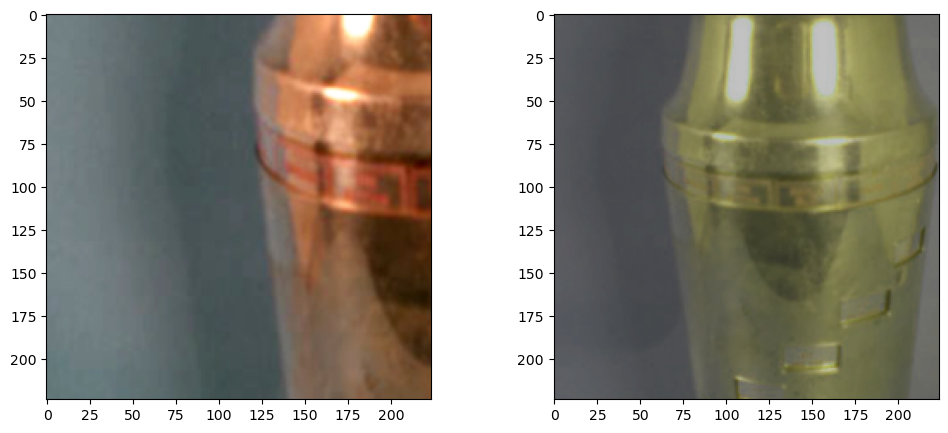

In [12]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
batch_ind = 0
axs[0].imshow(view_1_viz[batch_ind].permute(1, 2, 0))
axs[1].imshow(view_2_viz[batch_ind].permute(1, 2, 0))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


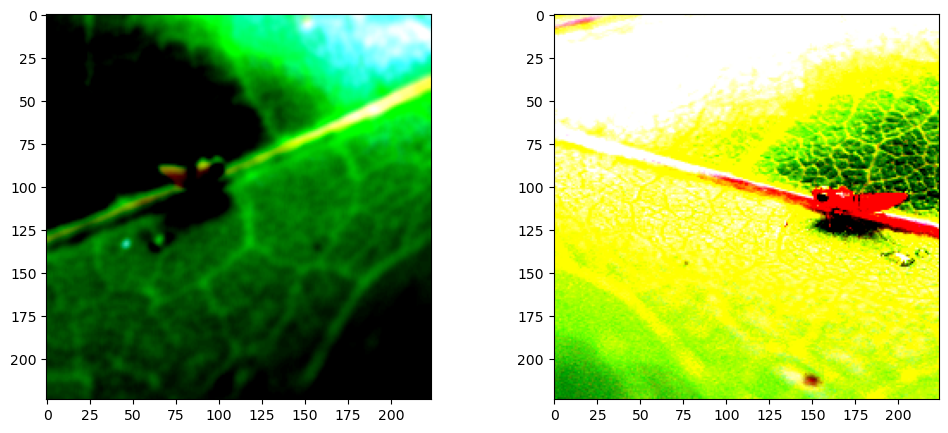

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(view_1[batch_ind].permute(1, 2, 0))
axs[1].imshow(view_2[batch_ind].permute(1, 2, 0))

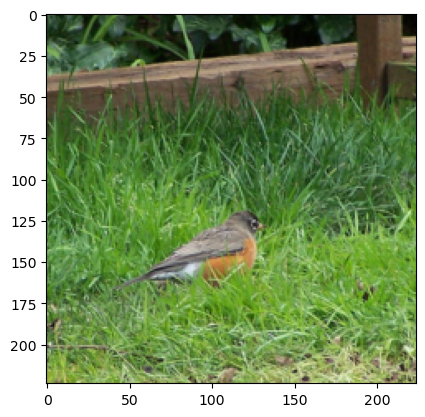

In [15]:
plt.imshow(test_batch_viz[0].permute(1, 2, 0))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


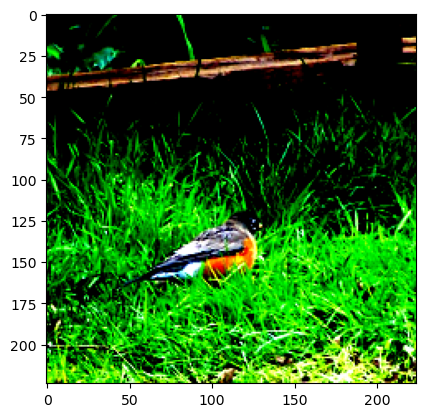

In [17]:
plt.imshow(img_batch[0].permute(1, 2, 0))